# ASR Homework Demo Notebook

This notebook demonstrates the trained Conformer-CTC model with BPE tokenization and GPT-2 rescoring.

## 1. Installation and Setup

In [ ]:
!git clone -b example/asr https://github.com/Tiltovskii/ASR_HW.git
%cd ASR_HW
!pip install -r requirements.txt
!pip install gdown

Cloning into 'ASR_HW'...
remote: Enumerating objects: 696, done.
remote: Counting objects: 100% (165/165), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 696 (delta 121), reused 108 (delta 107), pack-reused 531 (from 1)
Receiving objects: 100% (696/696), 398.96 KiB | 12.87 MiB/s, done.
Resolving deltas: 100% (352/352), done.
/content/ASR_HW
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.4/86.4 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.4/755.4 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 104.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 86.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
^C


In [74]:
!pip install --upgrade transformers==4.49.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 108.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 114.0 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.1
    Uninstalling tokenizers-0.22.1:
      Successfully uninstalled tokenizers-0.22.1
  Attempting uninstall: transformers
    Found existing installation: transformers 4.57.3
    Uninstalling transformers-4.57.3:
      Successfully uninstalled transformers-4.57.3


In [76]:
!pip install wget

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=6c75f9164178c8ce424c061d151bc35c28584ad009346bf704564dbe82345949
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget


## 2. Download Model Weights and Tokenizer

In [3]:
import os
import gdown

os.makedirs("ASR_HW/saved/ConformerV5_bs_16_bpe_1k_other", exist_ok=True)

weights_id = "1rEiXNyZ869CF38VU_p5gSVSzruBd_qQB"
tokenizer_id = "1VD35fvWte-rIFehP2A1ycPcVz034StER"

gdown.download(f'https://drive.google.com/uc?id={weights_id}', 'ASR_HW/saved/ConformerV5_bs_16_bpe_1k_other/model_best.pth', quiet=False)
gdown.download(f'https://drive.google.com/uc?id={tokenizer_id}', 'ASR_HW/src/text_encoder/bpe_tokenizer.json', quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1rEiXNyZ869CF38VU_p5gSVSzruBd_qQB
From (redirected): https://drive.google.com/uc?id=1rEiXNyZ869CF38VU_p5gSVSzruBd_qQB&confirm=t&uuid=1b83b6e6-6050-44f1-a6e1-56bb25e2e6ab
To: /content/ASR_HW/saved/ConformerV5_bs_16_bpe_1k_other/model_best.pth
100%|██████████| 260M/260M [00:01<00:00, 234MB/s]
Downloading...
From: https://drive.google.com/uc?id=1VD35fvWte-rIFehP2A1ycPcVz034StER
To: /content/ASR_HW/src/text_encoder/bpe_tokenizer.json
100%|██████████| 62.5k/62.5k [00:00<00:00, 47.3MB/s]


'ASR_HW/src/text_encoder/bpe_tokenizer.json'

## 3. Augmentation Visualization

Demonstrating the 4 required augmentations: Gain, WhiteNoise, PitchShift, and SpecAugment (Time/Frequency Masking).

In [8]:
%cd ASR_HW/

/content/ASR_HW


In [9]:
import torch
import matplotlib.pyplot as plt
import torchaudio
from src.transforms.wav_augs import Gain, WhiteNoise, PitchShift
from src.transforms.spec_augs import TimeMasking, FrequencyMasking

In [10]:
def plot_audio(wav, title):
    plt.figure(figsize=(10, 4))
    plt.plot(wav[0].numpy())
    plt.title(title)
    plt.show()

In [11]:
!wget https://www.kozco.com/tech/piano2.wav -O sample.wav

--2025-12-30 13:30:49--  https://www.kozco.com/tech/piano2.wav
Resolving www.kozco.com (www.kozco.com)... 74.81.95.187
Connecting to www.kozco.com (www.kozco.com)|74.81.95.187|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1210892 (1.2M) [audio/x-wav]
Saving to: ‘sample.wav’

sample.wav          100%[===================>]   1.15M  1.48MB/s    in 0.8s    

2025-12-30 13:30:51 (1.48 MB/s) - ‘sample.wav’ saved [1210892/1210892]



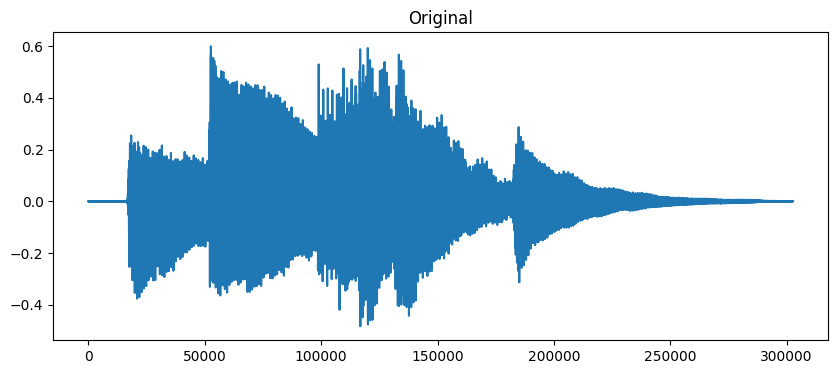

In [12]:
wav, sr = torchaudio.load("sample.wav")
plot_audio(wav, "Original")

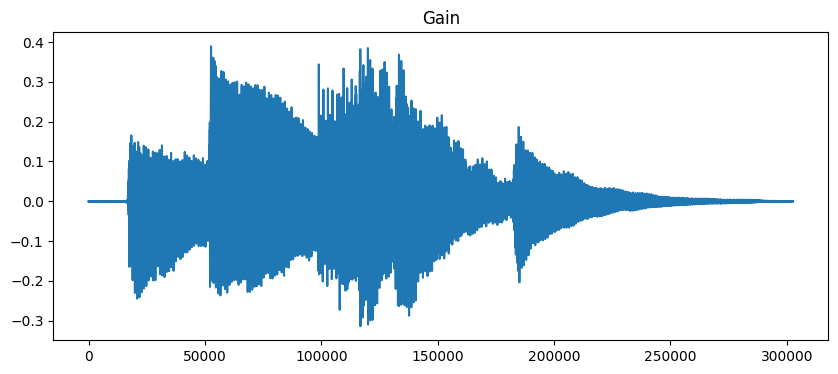

In [13]:
gain = Gain(p=1)
plot_audio(gain(wav.reshape(1, -1)).reshape(2, -1), "Gain")

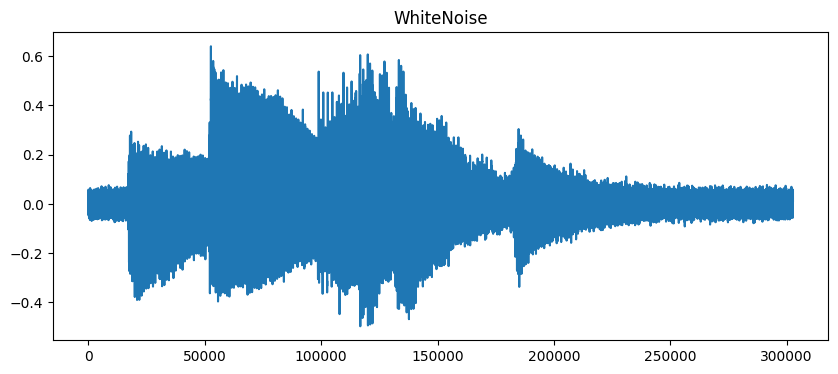

In [14]:
noise = WhiteNoise(min_snr_db=10, max_snr_db=30)
plot_audio(noise(wav), "WhiteNoise")

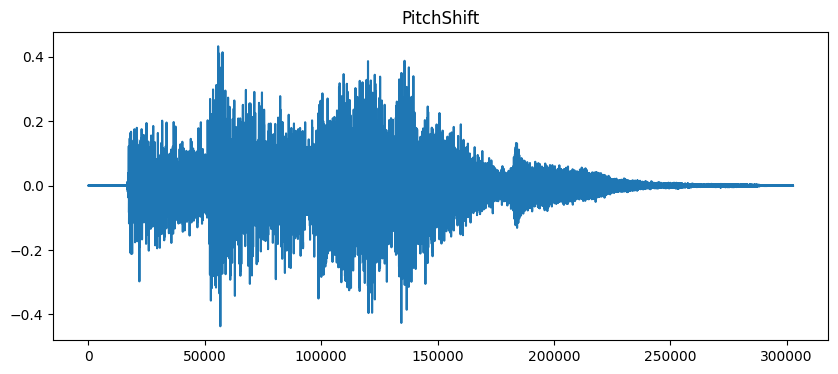

In [15]:
pitch = PitchShift(sample_rate=sr, n_steps_range=(4, 4))
plot_audio(pitch(wav), "PitchShift")

/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:584: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(


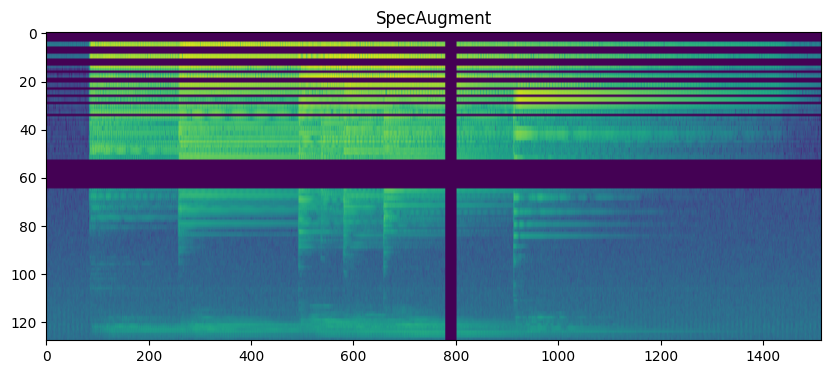

In [16]:
spec_gen = torchaudio.transforms.MelSpectrogram(sample_rate=sr)
spec = spec_gen(wav)

time_mask = TimeMasking(time_mask_param=30)
freq_mask = FrequencyMasking(freq_mask_param=15)
masked_spec = freq_mask(time_mask(spec))

plt.figure(figsize=(10, 4))
plt.imshow(torch.log(masked_spec[0] + 1e-9).numpy(), aspect='auto')
plt.title("SpecAugment")
plt.show()

## 4. Inference on Custom Dataset

Provide a GDrive link to your dataset zip file (format specified in README).

In [17]:
dataset_id = "1XhwXnLUYvYRKe1tSG2hUI6xmncwP1JSL"
!gdown --id {dataset_id} -O custom_dataset.zip
!unzip custom_dataset.zip -d custom_data_dir

Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: custom_data_dir/custom_test_other/audio/3538-163622-0011.flac  
  inflating: custom_data_dir/custom_test_other/audio/3538-163622-0012.flac  
  inflating: custom_data_dir/custom_test_other/audio/3538-163622-0013.flac  
  inflating: custom_data_dir/custom_test_other/audio/3538-163622-0014.flac  
  inflating: custom_data_dir/custom_test_other/audio/3538-163622-0015.flac  
  inflating: custom_data_dir/custom_test_other/audio/3538-163622-0016.flac  
  inflating: custom_data_dir/custom_test_other/audio/3538-163622-0017.flac  
  inflating: custom_data_dir/custom_test_other/audio/3538-163622-0018.flac  
  inflating: custom_data_dir/custom_test_other/audio/3538-163622-0019.flac  
  inflating: custom_data_dir/custom_test_other/audio/3538-163622-0020.flac  
  inflating: custom_data_dir/custom_test_other/audio/3538-163622-0021.flac  
  inflating: custom_data_dir/custom_test_other/audio/3538-163622-0022.flac  
  inflat

In [19]:
!python inference.py -cn conformer_bpe_inference \
    datasets="asr_custom" \
    datasets.custom.audio_dir="custom_data_dir/custom_test_other" \
    inferencer.save_path="custom_results"

2025-12-30 13:32:30.548094: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767101550.569932    2417 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767101550.576882    2417 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767101550.592999    2417 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767101550.593026    2417 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767101550.593030    2417 computation_placer.cc:177] computation placer alr

In [20]:
!python calc_metrics.py \
    --target_dir "custom_data_dir/custom_test_other/transcriptions" \
    --predicted_dir "data/saved/custom_results/custom"

Total files: 2939
Standard CER: 0.1093
Standard WER: 0.2371
